# Recommender Systems: EDA, Feature Engineering and Content-Based Recommenders

An investigation for the IBM Machine Learning Professional Certificate capstone.

1. Exploratory data analysis of the course catalogue and the enrolment ratings.
2. Text features for every course: bag of words, TF-IDF and Word2Vec document embeddings.
3. Content-based recommenders, scored by HitRate@10 and NDCG@10 on the shared leave-one-out split.

In [1]:
%matplotlib inline

import sys

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from gensim import corpora
from gensim.matutils import corpus2dense
from gensim.models import TfidfModel, Word2Vec
from nltk.tokenize import word_tokenize
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import STOPWORDS, WordCloud

sys.path.append("..")
from recsys import data, evaluation, recommenders, results, splits

for resource in ("punkt_tab", "averaged_perceptron_tagger_eng"):
    nltk.download(resource, quiet=True)

# Exploratory Data Analysis

## Course catalogue

In [2]:
course_df = data.load_course_genres()
course_df["TITLE"] = course_df["TITLE"].str.split().str.join(" ")
genres = list(course_df.columns[2:])

print(f"Courses in the catalogue: {len(course_df)}")
print(f"Genres ({len(genres)}): {', '.join(genres)}")
course_df.head()

Courses in the catalogue: 307
Genres (14): Database, Python, CloudComputing, DataAnalysis, Containers, MachineLearning, ComputerVision, DataScience, BigData, Chatbot, R, BackendDev, FrontendDev, Blockchain


,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson s...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0
4,GPXX0Z2PEN,containerizing packaging and running a spring ...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


### Word cloud of course titles

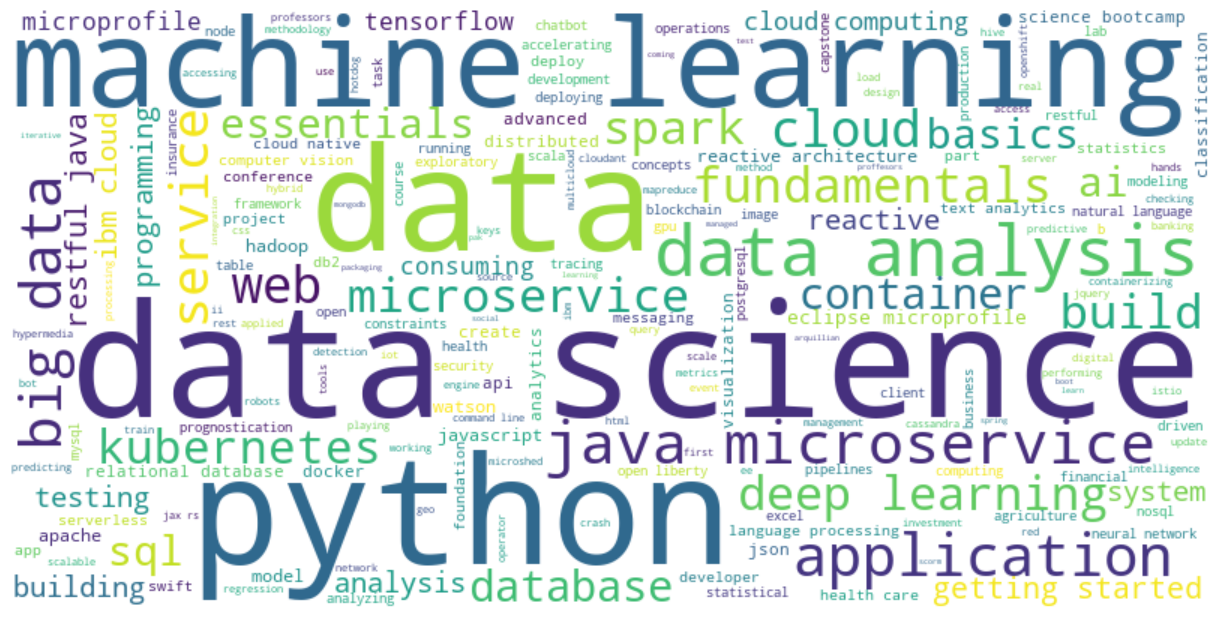

In [3]:
stop_words = set(STOPWORDS) | {"getting started", "using", "enabling", "template", "university", "end", "introduction", "basic"}
titles = " ".join(course_df["TITLE"])
wordcloud = WordCloud(stopwords=stop_words, background_color="white", width=800, height=400).generate(titles)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Computer science and data science terms dominate: python, data science, machine learning, cloud, big data.

### Courses per genre

Machine learning courses: 69 | machine learning and big data: 4
 COURSE_ID                                                               TITLE
GPXX0BUBEN insurance risk assessment with montecarlo method using apache spark
  TA0106EN                                             text analytics at scale
  BD0221EN                                                         spark mllib
excourse69                                      machine learning with big data


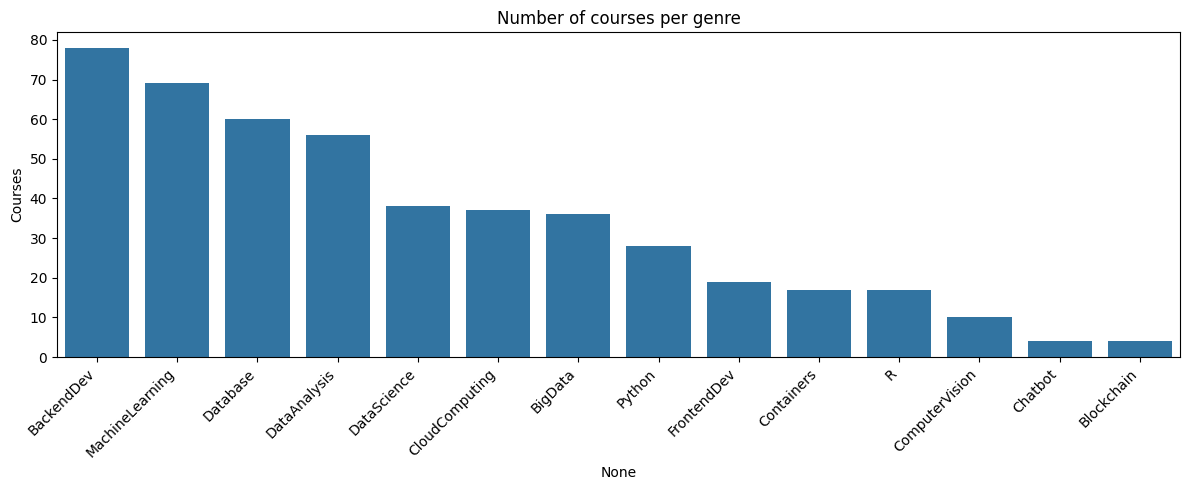

In [4]:
ml_courses = course_df[course_df["MachineLearning"] == 1]
ml_big_data = course_df[(course_df["MachineLearning"] == 1) & (course_df["BigData"] == 1)]
print(f"Machine learning courses: {len(ml_courses)} | machine learning and big data: {len(ml_big_data)}")
print(ml_big_data[["COURSE_ID", "TITLE"]].to_string(index=False))

genre_totals = course_df[genres].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=genre_totals.index, y=genre_totals.values)
plt.title("Number of courses per genre")
plt.ylabel("Courses")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Very few courses cover Blockchain, Chatbot or Computer Vision compared with Backend Development and Machine Learning.

## Enrolments and ratings
Each row is one enrolment: a user, a course and a rating from 3 (below expectations) to 5 (maximum rating).

In [5]:
ratings = data.load_ratings()
enrolments_per_user = ratings.groupby("user").size()

print(f"Enrolments: {len(ratings):,}")
print(f"Users: {ratings['user'].nunique():,} | rated courses: {ratings['item'].nunique()} of {len(course_df)} in the catalogue")
print(f"Share of the user x course matrix that is filled: {len(ratings) / (ratings['user'].nunique() * ratings['item'].nunique()):.1%}")
print(f"Users with a single enrolment: {(enrolments_per_user == 1).sum():,}")
print()
print("Rating distribution:")
print(ratings["rating"].value_counts(normalize=True).sort_index().round(3).to_string())

Enrolments: 233,306
Users: 33,901 | rated courses: 126 of 307 in the catalogue
Share of the user x course matrix that is filled: 5.5%
Users with a single enrolment: 8,320

Rating distribution:
rating
3    0.334
4    0.334
5    0.332


The three ratings are almost exactly equally common. Section 3 of `model_comparison.ipynb` tests whether ratings depend
on the user or the course. They do not, which is why this project focuses on predicting enrolments.

count    33901.00
mean         6.88
std          5.82
min          1.00
25%          2.00
50%          6.00
75%          9.00
max         61.00


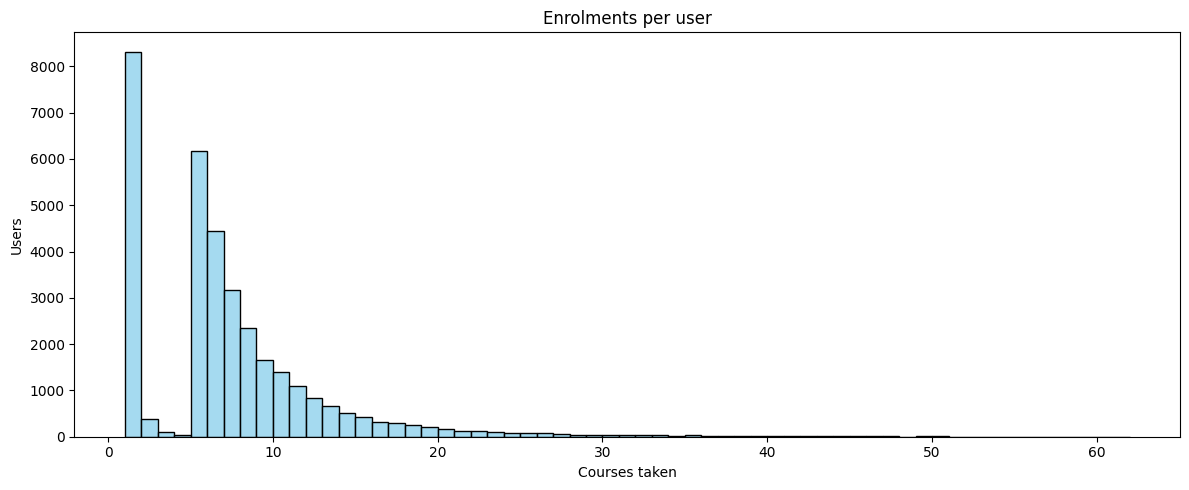

In [6]:
print(enrolments_per_user.describe().round(2).to_string())

plt.figure(figsize=(12, 5))
sns.histplot(enrolments_per_user, bins=range(1, enrolments_per_user.max() + 2), color="skyblue", edgecolor="black")
plt.title("Enrolments per user")
plt.xlabel("Courses taken")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

### Most popular courses

In [7]:
course_enrolments = ratings.groupby("item").size().sort_values(ascending=False)
top_20 = (
    course_enrolments.head(20)
    .rename("enrolments")
    .to_frame()
    .join(course_df.set_index("COURSE_ID")["TITLE"])
)
print(top_20[["TITLE", "enrolments"]].to_string())
print(f"\nThe top 20 courses account for {top_20['enrolments'].sum() / len(ratings):.1%} of all enrolments.")

                                                   TITLE  enrolments
item                                                                
PY0101EN                         python for data science       14936
DS0101EN                    introduction to data science       14477
BD0101EN                                    big data 101       13291
BD0111EN                                      hadoop 101       10599
DA0101EN                       data analysis with python        8303
DS0103EN                        data science methodology        7719
ML0101ENv3                  machine learning with python        7644
BD0211EN                            spark fundamentals i        7551
DS0105EN    data science hands on with open source tools        7199
BC0101EN                           blockchain essentials        6719
DV0101EN                  data visualization with python        6709
ML0115EN                               deep learning 101        6323
CB0103EN                          

Enrolments are concentrated in a small set of introductory courses, so recommending the most popular courses is a strong
baseline that every model has to beat.

# Feature Engineering

Each course is represented by its title and description, tokenised with NLTK. Stop words, numbers and function words
(prepositions, adverbs, pronouns and similar tags) are removed.

In [8]:
course_text = data.load_course_text()
course_text["TITLE"] = course_text["TITLE"].str.split().str.join(" ")
course_text["text"] = course_text["TITLE"] + " " + course_text["DESCRIPTION"]

FUNCTION_WORD_TAGS = {"WDT", "WP", "WRB", "FW", "IN", "JJR", "JJS", "MD", "PDT", "POS", "PRP", "RB", "RBR", "RBS", "RP"}


def tokenize_course(text):
    tokens = [w for w in word_tokenize(str(text)) if w.lower() not in stop_words and not w.isnumeric()]
    return [word for word, tag in nltk.pos_tag(tokens) if tag not in FUNCTION_WORD_TAGS]


course_text["tokens"] = course_text["text"].apply(tokenize_course)
print(f"Courses: {len(course_text)} | mean tokens per course: {course_text['tokens'].str.len().mean():.1f}")
print("Example:", course_text["tokens"].iloc[0][:12])

Courses: 307 | mean tokens per course: 45.9
Example: ['robots', 'coming', 'build', 'iot', 'apps', 'watson', 'swift', 'red', 'fun', 'iot', 'learn', 'way']


## Bag of words and TF-IDF
Bag of words counts each token per course. TF-IDF reweights the counts so that tokens common to many courses count less.

In [9]:
dictionary = corpora.Dictionary(course_text["tokens"])
corpus = [dictionary.doc2bow(tokens) for tokens in course_text["tokens"]]
bow_matrix = corpus2dense(corpus, num_terms=len(dictionary)).T
tfidf_matrix = corpus2dense(TfidfModel(corpus)[corpus], num_terms=len(dictionary)).T

print(f"Vocabulary: {len(dictionary):,} tokens | BoW and TF-IDF matrices: {bow_matrix.shape}")

Vocabulary: 2,690 tokens | BoW and TF-IDF matrices: (307, 2690)


## Word2Vec document embeddings
Word2Vec is trained on the course texts, and each course is the average of its word vectors.
With only 307 short documents, the averaged vectors share one large common direction that makes every pair of courses
look almost identical (cosine similarity close to 1). Subtracting the mean document vector removes that direction.

In [10]:
w2v = Word2Vec(sentences=course_text["tokens"], vector_size=100, window=5, min_count=2,
               epochs=50, workers=1, seed=splits.SEED)


def document_vector(tokens):
    vectors = [w2v.wv[t] for t in tokens if t in w2v.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(w2v.vector_size)


w2v_matrix = np.vstack(course_text["tokens"].apply(document_vector))
raw_similarity = cosine_similarity(w2v_matrix)
w2v_matrix = w2v_matrix - w2v_matrix.mean(axis=0)
off_diagonal = ~np.eye(len(w2v_matrix), dtype=bool)
print(f"Mean pairwise cosine similarity before centring: {raw_similarity[off_diagonal].mean():.3f}")
print(f"Mean pairwise cosine similarity after centring: {cosine_similarity(w2v_matrix)[off_diagonal].mean():.3f}")

Mean pairwise cosine similarity before centring: 0.578
Mean pairwise cosine similarity after centring: 0.014


## Course similarity
Cosine similarity between every pair of courses, for each representation.

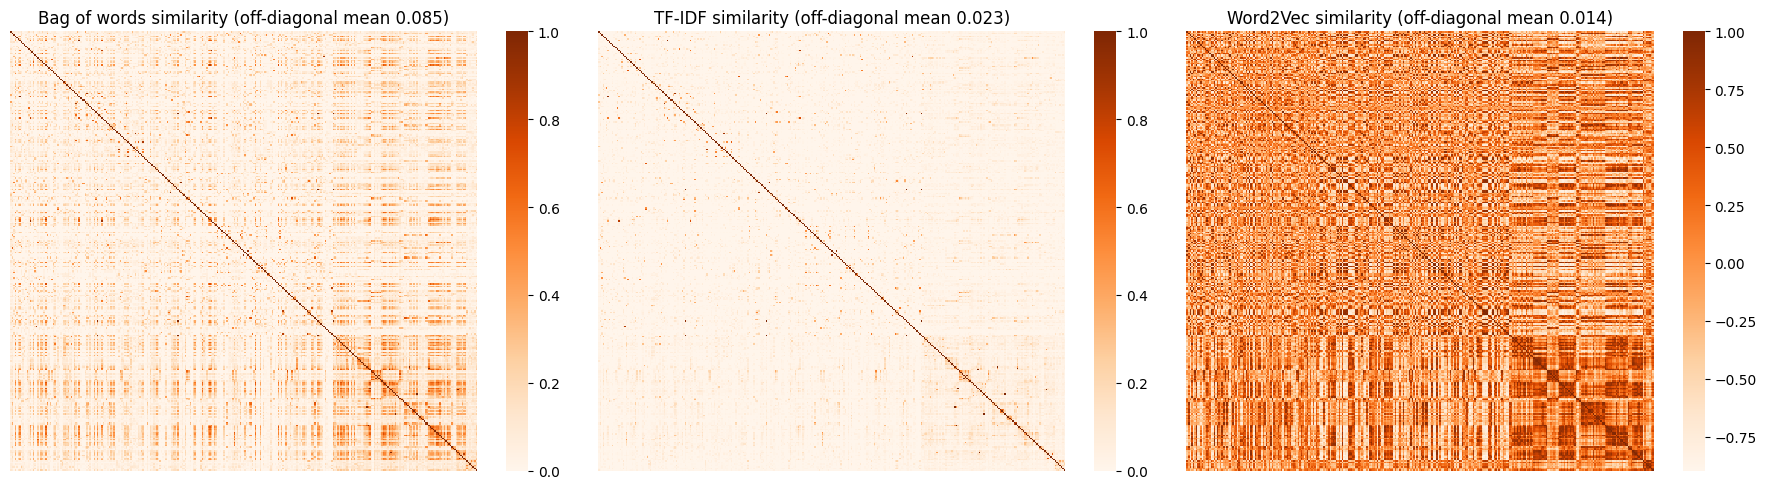

In [11]:
similarities = {
    "Bag of words": cosine_similarity(bow_matrix),
    "TF-IDF": cosine_similarity(tfidf_matrix),
    "Word2Vec": cosine_similarity(w2v_matrix),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, sim) in zip(axes, similarities.items()):
    values = sim[off_diagonal]
    sns.heatmap(sim, ax=ax, cmap="Oranges", vmin=values.min(), vmax=values.max(), xticklabels=False, yticklabels=False)
    ax.set_title(f"{name} similarity (off-diagonal mean {values.mean():.3f})")
plt.tight_layout()
plt.show()

### Most similar courses to "machine learning with python"
The first version of this example built bag-of-words vectors that also contained the course's row number, which
dominated the cosine similarity (every course scored above 0.999). Here each representation is compared on its own.

In [12]:
course_ids = course_text["COURSE_ID"].to_numpy()
target = int(np.flatnonzero(course_ids == "ML0101ENv3")[0])
print(f"Target: {course_text['TITLE'].iloc[target]} ({course_ids[target]})")

for name, sim in similarities.items():
    scores = sim[target].copy()
    scores[target] = -np.inf
    print(f"\n{name}:")
    for item in np.argsort(-scores)[:5]:
        print(f"  {scores[item]:.3f}  {course_text['TITLE'].iloc[item]}")

Target: machine learning with python (ML0101ENv3)

Bag of words:
  0.693  machine learning with r
  0.633  machine learning for all
  0.613  machine learning
  0.547  introduction to tensorflow for artificial intelligence machine learning and deep learning
  0.528  machine learning dimensionality reduction

TF-IDF:
  0.376  machine learning with r
  0.281  machine learning with big data
  0.276  machine learning for all
  0.265  machine learning
  0.241  applied machine learning in python

Word2Vec:
  0.972  machine learning with r
  0.932  machine learning dimensionality reduction
  0.932  machine learning with python
  0.922  machine learning for all
  0.914  predicting customer satisfaction


# Content-Based Recommenders

Four content-based recommenders, scored on the shared leave-one-out split. Every user profile is built from the user's
training enrolments only. The held-out test course is never part of it.

- **Genre profile:** the user's profile is the sum of the genre vectors of their courses. Each unseen course is scored by
  the dot product of that profile with the course's genres.
- **BoW, TF-IDF and Word2Vec similarity:** each unseen course is scored by its total similarity to the courses the user has taken.

Only the 126 courses that appear in the enrolment data are ranked, so every family in the project ranks the same candidates.

In [13]:
index = data.Index(ratings)
train_loo, test_loo = splits.leave_one_out(ratings)

genre_features = course_df.set_index("COURSE_ID").loc[index.items, genres].to_numpy(dtype=float)
rows = pd.Index(course_ids).get_indexer(index.items)


def item_similarity(sim):
    sub = sim[np.ix_(rows, rows)].copy()
    np.fill_diagonal(sub, 0.0)
    return sub


content_models = {
    "Genre profile": lambda matrix, users: recommenders.profile_scores(matrix, users, genre_features),
}
for name, sim in similarities.items():
    sub = item_similarity(sim)
    content_models[f"{name} similarity"] = lambda matrix, users, sub=sub: recommenders.similarity_scores(matrix, users, sub)

ranking_rows = []
for name, score_fn in content_models.items():
    scores = evaluation.evaluate_ranking(score_fn, train_loo, test_loo, index)
    ranking_rows.append({"family": "Content-based", "model": name, **scores})

pd.DataFrame(ranking_rows).sort_values("ndcg@10", ascending=False).round(4)

,family,model,hit_rate@10,ndcg@10
2,Content-based,TF-IDF similarity,0.3527,0.1782
1,Content-based,Bag of words similarity,0.2757,0.1426
3,Content-based,Word2Vec similarity,0.2596,0.1399
0,Content-based,Genre profile,0.1616,0.0626


In [14]:
results.save(ranking_rows, "ranking", source="EDA_FE_content_rec");

### Example recommendations
Top 5 TF-IDF recommendations for one test user, next to the courses they took.

In [15]:
titles = course_df.set_index("COURSE_ID").loc[index.items, "TITLE"].to_numpy()
user_row = index.user_to_idx.loc[test_loo["user"].iloc[0]]
train_matrix = splits.interaction_matrix(train_loo, index)
taken = train_matrix[user_row].toarray().ravel() > 0

scores = content_models["TF-IDF similarity"](train_matrix, np.array([user_row]))[0]
scores[taken] = -np.inf

print("Taken:")
for title in titles[taken][:8]:
    print(f"  {title}")
print("Recommended:")
for item in np.argsort(-scores)[:5]:
    print(f"  {titles[item]}")

Taken:
  blockchain essentials
  big data 101
  hadoop 101
  apache pig 101
  simplifying data pipelines with apache kafka
  moving data into hadoop
  controlling hadoop jobs using oozie
  developing distributed applications using zookeeper
Recommended:
  deep learning with tensorflow
  deep learning with tensorflow
  text analysis
  data science with open data
  accelerating deep learning with gpus


Some courses appear more than once in the catalogue under different ids (older and newer versions of the same course),
so the same title can be recommended twice, or show up as the most similar course to itself.

Content-based recommenders only know what a user has already taken. They cannot suggest a course from a genre the user has
not tried yet, even if similar users often take it next. `model_comparison.ipynb` compares them with the other families.